Import the liraries.

In [21]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

Create a dataset (regression problem).

In [22]:
X,y = make_regression(n_samples=4, n_informative=1, n_features=1, n_targets=1, noise=80, random_state=13) # Create a dataset with 4 samples, 1 feature, and some noise

Plot the data.

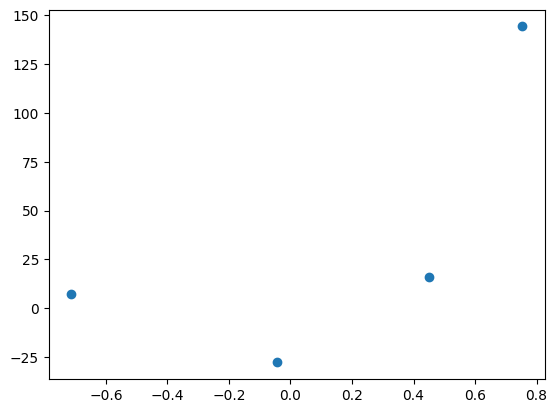

In [23]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

Train the model with linear regression and plot the best fit line.

[78.35063668] 26.15963284313262


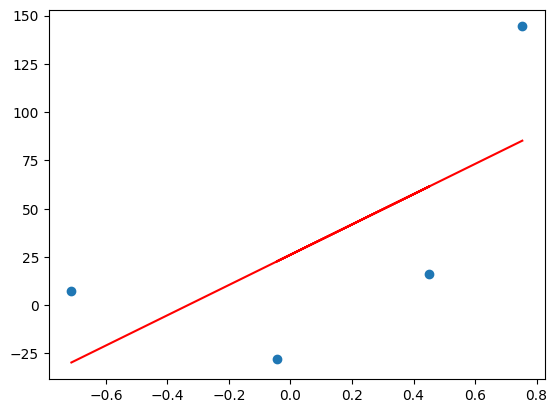

In [24]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X,y)
print(model.coef_, model.intercept_)
plt.scatter(X,y)
plt.plot(X, model.predict(X), color='red')

Applying the Gradient Descent to find predicted values.

In [25]:
# Lets apply Gradient Descent assuming slope is constant m = 78.35
# and let's assume the starting value for intercept c = 0
y_pred = ((78.35 * X) + 0).reshape(4)

Plot and compare the OLS vs GD with specific m and c values.

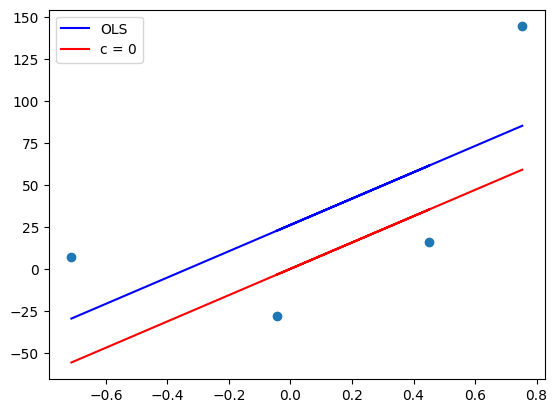

In [26]:

plt.scatter(X,y)
plt.plot(X,model.predict(X),color='blue',label='OLS')
plt.plot(X,y_pred,color='red',label='c = 0')
plt.legend()
plt.show()

Slope of loss function.

In [27]:
m = 78.35
c = 100

loss_slope = -2 * np.sum(y - m*X.ravel() - c)  # ravel() is used to convert 2D array to 1D array.
loss_slope # This is the slope of the loss function with respect to m (the coefficient) 

np.float64(590.7223659179078)

Find the step-size using learning rate and slope of loss function.

In [28]:
# Lets take learning rate = 0.1
lr = 0.1

step_size = loss_slope*lr
step_size

np.float64(59.072236591790784)

The new intercept using Gradient Descent formula.

In [29]:
# Calculating the new intercept
c = c - step_size
c

np.float64(40.927763408209216)

Plot and compare the OLS vs GD.

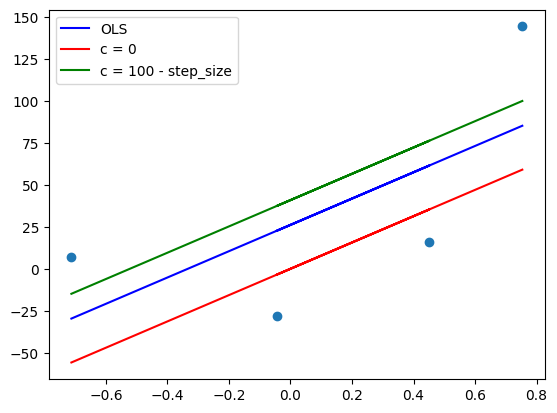

In [30]:
y_pred1 = ((78.35 * X) + c).reshape(4)

plt.scatter(X,y)
plt.plot(X,model.predict(X),color='blue',label='OLS')
plt.plot(X,y_pred,color='red',label='c = 0')
plt.plot(X,y_pred1,color='green',label='c = 100 - step_size')
plt.legend()
plt.show()

Repeat the step for second iteration and plot the comparitive graph.

118.14447318358157
11.814447318358157
29.11331608985106


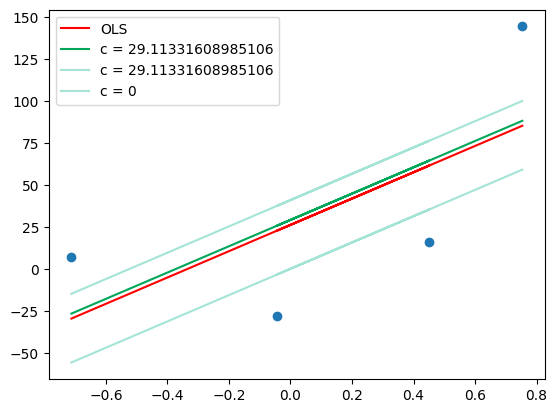

In [31]:
# Iteration 2
loss_slope = -2 * np.sum(y - m*X.ravel() - c)
print(loss_slope)

step_size = loss_slope*lr
print(step_size)

c = c - step_size
print(c)

y_pred2 = ((78.35 * X) + c).reshape(4)

plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red',label='OLS')
plt.plot(X,y_pred2,color='#00a65a',label='c = {}'.format(c))
plt.plot(X,y_pred1,color='#A3E4D7',label='c = {}'.format(c))
plt.plot(X,y_pred,color='#A3E4D7',label='c = 0')
plt.legend()
plt.show()

Repeat the step for second iteration and plot the comparitive graph.

23.62889463671634
2.362889463671634
26.750426626179426


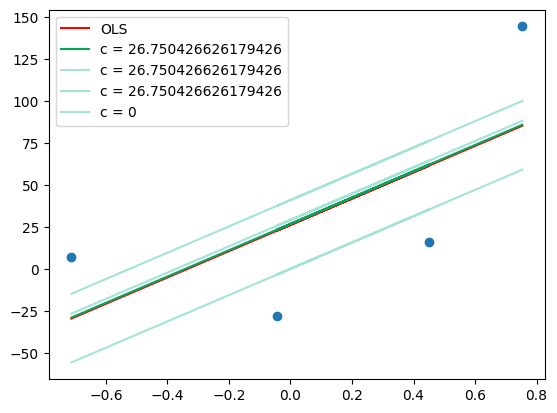

In [32]:
# Iteration 3
loss_slope = -2 * np.sum(y - m*X.ravel() - c)
print(loss_slope)

step_size = loss_slope * lr
print(step_size)

c = c - step_size
print(c)

y_pred3 = ((78.35 * X) + c).reshape(4)
plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red',label='OLS')
plt.plot(X,y_pred3,color='#00a65a',label='c = {}'.format(c))
plt.plot(X,y_pred2,color='#A3E4D7',label='c = {}'.format(c))
plt.plot(X,y_pred1,color='#A3E4D7',label='c = {}'.format(c))
plt.plot(X,y_pred,color='#A3E4D7',label='c = 0')
plt.legend()
plt.show()

Loop through all epochs and plot corresponding best fit line.

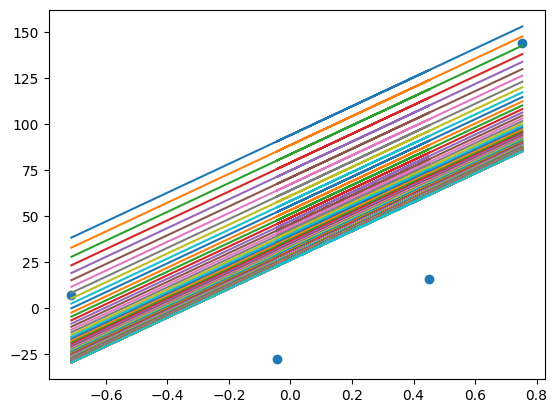

In [33]:
c = 100
m = 78.35
lr = 0.01
epochs = 100

for i in range(epochs):
    loss_slope = -2 * np.sum(y - m*X.ravel() - c)
    step_size = loss_slope * lr
    c = c - step_size

    y_pred = m * X + c
    plt.plot(X, y_pred)
plt.scatter(X,y)


Make another similiar regression problem.

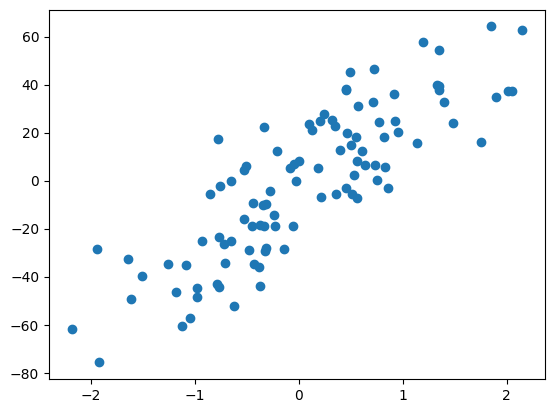

In [34]:
x,y = make_regression(n_samples=100, n_informative=1, n_features=1, n_targets=1, noise=20, random_state=13)
plt.scatter(x,y)
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=13)

Train the data.

In [35]:
model = LinearRegression()
model.fit(x_train, y_train)
print(model.coef_, model.intercept_)
y_pred = model.predict(x_test)
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)


[28.67684216] -2.088699766134101


0.71337703667083

Self made GD class/ function.

In [36]:
class SelfMadeGD:
    def __init__(self, m, c, learning_rate, epochs):
        self.m = m
        self.c = c
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X, y):
        for i in range(self.epochs):
            loss_slope_c = -2 * np.sum(y - self.m*X.ravel() - self.c)
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.c) * X.ravel())
            self.m -= self.lr * loss_slope_m
            self.c -= self.lr * loss_slope_c
        
    def predict(self, X):
        return self.m * X + self.c

Training the data and finding r2 score.

In [37]:
gd = SelfMadeGD(m=100, c=100, learning_rate=0.01, epochs=100)
gd.fit(x_train, y_train)
print(gd.m, gd.c)

28.6768421605969 -2.0886997661340994


In [38]:
y_pred_gd = gd.predict(x_test)
r2_score(y_test, y_pred_gd)

0.7133770366708301

The animations telling us the impact of different values of m and b. 

https://github.com/campusx-official/100-days-of-machine-learning/blob/main/day51-gradient-descent/gradient-descent-animation(onlyb).ipynb

https://github.com/campusx-official/100-days-of-machine-learning/blob/main/day51-gradient-descent/gradient-descent-animation(both-m-and-b).ipynb

https://github.com/campusx-official/100-days-of-machine-learning/blob/main/day51-gradient-descent/gradient-descent-3d.ipynb